In [1]:
from google.colab import drive
drive.mount('/content/drive/')



Mounted at /content/drive/


In [2]:
import os
os.chdir('/content/drive/MyDrive/satellite-altimetry-course')


In [3]:
!pip install cartopy
!pip install netCDF4
!pip install pyrsimg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 36.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.7 MB/s eta 0:00:00


In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import netCDF4 as nc
import numpy as np
from pyrsimg import readTiff, imgShow


In [5]:
path_s3l2 = 'data/radar/S3A_SR_2_LAN____20230824T030706_20230824T035734_20230919T063755_3028_102_289______PS1_O_NT_004.SEN3/enhanced_measurement.nc'
path_rsimg = 'data/rsimg/dianchi_s2_20200511_wgs84_resam50m.tif'


In [7]:
s3l2 = nc.Dataset(path_s3l2)
rsimg = readTiff(path_rsimg)

In [10]:
print('变量数：')
len(s3l2.variables.keys())
list(s3l2.variables.keys())


变量数：


['time_01',
 'time_20_ku',
 'time_20_c',
 'echo_sample_ind',
 'UTC_day_01',
 'UTC_sec_01',
 'UTC_day_20_ku',
 'UTC_sec_20_ku',
 'UTC_day_20_c',
 'UTC_sec_20_c',
 'UTC_time_1hz_20_ku',
 'UTC_time_1hz_20_c',
 'lat_01',
 'lon_01',
 'lat_20_ku',
 'lon_20_ku',
 'lat_20_c',
 'lon_20_c',
 'lat_cor_20_ku',
 'lon_cor_20_ku',
 'lat_cor_20_c',
 'lon_cor_20_c',
 'surf_type_01',
 'surf_type_20_ku',
 'surf_type_20_c',
 'surf_class_01',
 'surf_class_20_ku',
 'surf_class_20_c',
 'rad_surf_type_01',
 'angle_coast_01',
 'angle_coast_20_ku',
 'angle_coast_20_c',
 'dist_coast_01',
 'dist_coast_20_ku',
 'dist_coast_20_c',
 'alt_01',
 'alt_20_ku',
 'alt_20_c',
 'orb_alt_rate_01',
 'orb_alt_rate_20_ku',
 'orb_alt_rate_20_c',
 'tracker_range_20_ku',
 'tracker_range_20_c',
 'tracker_range_20_plrm_ku',
 'h0_nav_dem_20_ku',
 'agc_01_ku',
 'agc_01_c',
 'agc_01_plrm_ku',
 'agc_20_ku',
 'agc_20_c',
 'agc_20_plrm_ku',
 'agc_numval_01_ku',
 'agc_numval_01_c',
 'agc_numval_01_plrm_ku',
 'agc_rms_01_ku',
 'agc_rms_01_c

In [12]:
s3l2.variables['range_ocean_qual_20_c']


<class 'netCDF4._netCDF4.Variable'>
int8 range_ocean_qual_20_c(time_20_c)
    _FillValue: 127
    long_name: quality flag for the 'ocean' altimeter range : 20 Hz C band
    flag_values: [0 1]
    flag_meanings: Yes No
    coordinates: lon_20_c lat_20_c
    comment: LRM mode : ocean retracking, SAR mode : ocean/coastal retracking. Flag indicating the use or not of the 20-Hz estimate of the ocean altimeter range in the computation of 1Hz estimate
unlimited dimensions: 
current shape = (39477,)
filling on

In [23]:
lat_20_ku = s3l2['lat_cor_20_ku'][:]
lon_20_ku = s3l2['lon_cor_20_ku'][:]


cycle_102-pass_578


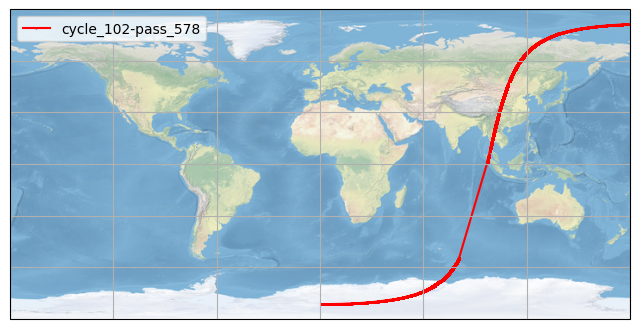

In [26]:
proj = ccrs.PlateCarree(central_longitude=0)
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection=proj)
ax.stock_img()
orbit = 'cycle_' + str(s3l2.cycle_number) + '-pass_'+str(s3l2.pass_number)
print(orbit)
ax.plot(lon_20_ku, lat_20_ku, marker='.', markersize=1, label=orbit, color='red')
ax.gridlines()
ax.legend()


Text(0.5, 1.0, 'sentinel-3 data')

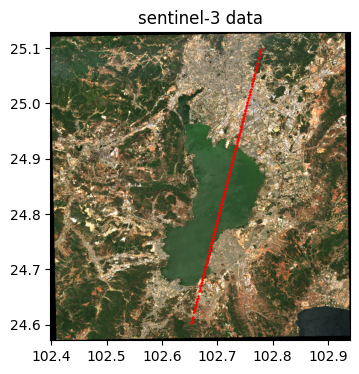

In [32]:
ids = np.where((lat_20_ku>24.6) & (lat_20_ku<25.1))
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111)
imgShow(rsimg.array, extent=rsimg.geoextent, ax=ax)
ax.scatter(x=lon_20_ku[ids], y=lat_20_ku[ids], s=0.5, color='red')
plt.title('sentinel-3 data')


In [33]:
s3l2['elevation_ocog_20_ku']


<class 'netCDF4._netCDF4.Variable'>
int32 elevation_ocog_20_ku(time_20_ku)
    _FillValue: 2147483647
    long_name: corrected altimeter elevation from OCOG (ice-1) retracker : 20 Hz Ku band
    units: m
    add_offset: 0.0
    scale_factor: 0.0001
    coordinates: lon_20_ku lat_20_ku
    comment: LRM mode : OCOG (ice-1) retracking, SAR mode : OCOG (ice-1)  retracking. Instrumental corrections included : USO drift correction (uso_cor_[x1]_[x2]), internal path correction (int_path_cor_[x1]_[x2]),  distance antenna-COG (cog_cor_[x1]_[x2]) and Doppler slope correction (dop_slope_cor_[x1]_[x2]). Geophysical corrections included: GIM-derived ionospheric correction on Ku band (iono_cor_gim_[x1]_ku), model dry tropospheric correction (mod_dry_tropo_cor_meas_altitude_[x1]_[x2]),  model wet tropospheric correction (mod_wet_tropo_cor_meas_altitude_[x1]_[x2]), solid earth tide height (solid_earth_tide_[x1]_[x2]), geocentric ocean tide height solution 2 = FES (ocean_tide_sol2_[x1]_[x2], on ocean/s

(1854.5, 1855.6)

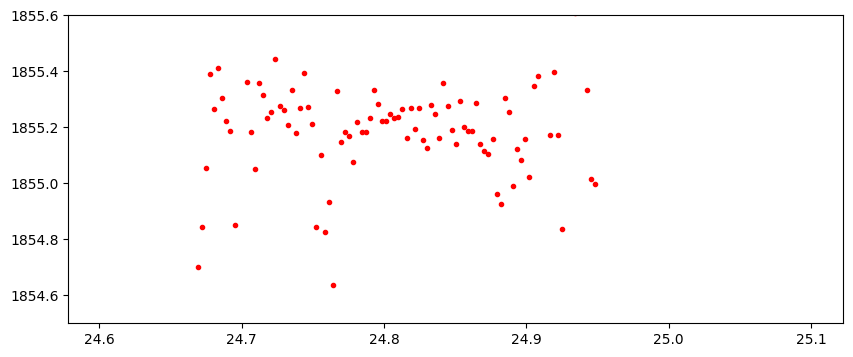

In [36]:
ele_ocog = s3l2['elevation_ocog_20_ku'][:]
plt.figure(figsize=(10,4))
plt.plot(lat_20_ku[ids], ele_ocog[ids], 'r.')
plt.ylim(1854.5, 1855.6)

In [43]:
ids = np.where((lat_20_ku>24.8) & (lat_20_ku<24.81))[0]
id = ids[0]
wf_sar =s3l2['waveform_20_ku'][:][id]
wf_lrm =s3l2['waveform_20_plrm_ku'][:][id]
print(wf_sar.shape)
print(wf_lrm.shape)


(128,)
(128,)


Text(0.5, 1.0, 'lrm waveform')

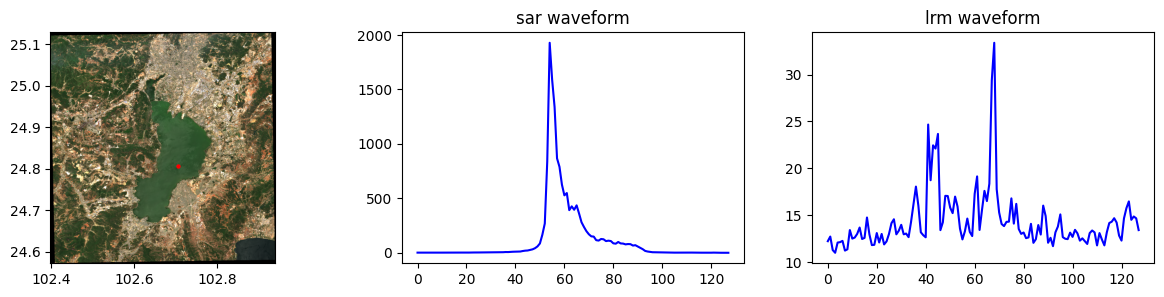

In [52]:
fig, ax = plt.subplots(1,3, figsize=(15,3))
imgShow(rsimg.array, extent=rsimg.geoextent, ax=ax[0])
ax[0].scatter(x=lon_20_ku[id], y=lat_20_ku[id], s=4.5, color='red')
ax[1].plot(wf_sar, color='blue')
ax[1].set_title('sar waveform')
ax[2].plot(wf_lrm, color='blue')
ax[2].set_title('lrm waveform')


